# Анализ файла brain.bin

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Шаг 1: Загрузка и анализ файла brain.bin

In [8]:
with open('brain.bin', 'rb') as f:
    brain_bytes = f.read()

raw_data = np.frombuffer(brain_bytes, dtype=np.uint8)
brain_weights = raw_data.astype(np.float32) / 255.0

print(f"Загружено синапсов: {len(brain_weights)}")

Загружено синапсов: 230144068


### Шаг 2: Визуализация распределения важности нейронов

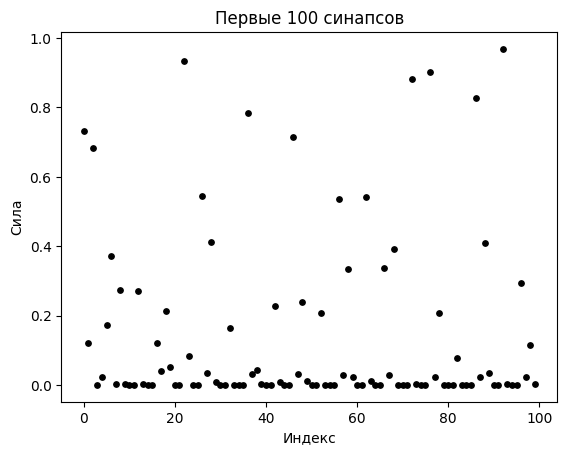

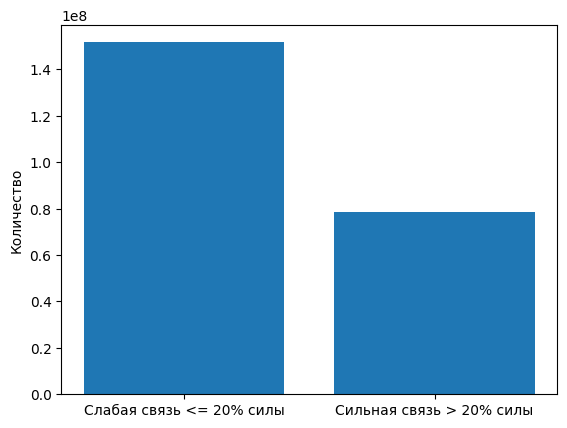

In [11]:
plt.scatter(range(100), brain_weights[:100], s=15, c='black')
plt.title("Первые 100 синапсов")
plt.xlabel("Индекс")
plt.ylabel("Сила")
plt.show()
w = brain_weights
c0 = (w <= 0.2).sum()
c1 = (w > 0.2).sum()
plt.bar(['Слабая связь <= 20% силы', 'Сильная связь > 20% силы'], [c0, c1])
plt.ylabel("Количество")
plt.show()

### Шаг 3: Определение значимых связей среди обычных

In [13]:
N = 50000
w = brain_weights[:N]
X = np.column_stack([w[:-2], w[2:]])
y = (w[1:-1] > 0.2).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = LogisticRegression()
clf.fit(X_train, y_train)
acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Точность определения сильной связи: {acc * 100:.1f}%")

Точность определения сильной связи: 69.6%
